<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_01_Aluno_Intro_Deep_Learning_IA_Generativa_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 – Introdução ao Deep Learning e IA Generativa

**Curso:** Deep Learning e Inteligência Artificial Generativa Aplicada  
**Carga da aula:** 4 horas  
**Estratégia:** aula expositiva dialogada com demonstração prática em Google Colab.

## Capacidades trabalhadas
- Construir redes neurais artificiais.
- Demonstrar atenção a detalhes.

## Conhecimentos da aula
- Conceito de Inteligência Artificial.
- Machine Learning e Deep Learning.
- Diferença entre redes rasas e redes profundas.
- Aplicações industriais de Deep Learning.

## Evidência de aprendizagem
Ao final, o aluno deverá entregar um notebook com: leitura do dataset, análise inicial, comparação entre um modelo raso e uma rede neural simples, além de respostas técnicas sobre IA, ML, DL e aplicações industriais.

> **Versão do aluno:** complete os campos indicados por `____` e responda às questões técnicas.

## 1. Contextualização

Nesta aula, você utilizará um dataset fictício de monitoramento industrial. Seu objetivo é classificar a operação da máquina como **normal** ou **risco_falha**.

Durante a atividade, observe como um modelo raso de Machine Learning pode ser comparado a uma rede neural inicial.

In [ ]:
# Célula 1 - Importe as bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carregamento do dataset

Envie o arquivo CSV para o Google Colab e complete o nome do arquivo na célula abaixo.

In [ ]:
# Célula 2 - Leia o dataset
arquivo = '/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula1_intro_deep_learning_industrial.csv'
df = pd.read_csv(arquivo)

print('Dimensão do dataset:', df.shape)
df.head()

# df.tail()
# df.describe().T
# df.info()
# df.isnull().sum().sum()
# df.isna().sum()




SyntaxError: invalid syntax (2197695030.py, line 16)

In [ ]:
# Célula 3 - Analise a estrutura dos dados
df.info()

df.describe(include="all")

print('Valores ausentes por coluna:')
print(df.isna().sum())

print('Distribuição da classe alvo:')
print(df['classe_operacao'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_amostra           420 non-null    int64  
 1   maquina              420 non-null    object 
 2   turno                420 non-null    object 
 3   temperatura_motor_c  416 non-null    float64
 4   vibracao_mm_s        416 non-null    float64
 5   corrente_a           416 non-null    float64
 6   tempo_ciclo_s        416 non-null    float64
 7   pressao_bar          416 non-null    float64
 8   classe_operacao      420 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 29.7+ KB
Valores ausentes por coluna:
id_amostra             0
maquina                0
turno                  0
temperatura_motor_c    4
vibracao_mm_s          4
corrente_a             4
tempo_ciclo_s          4
pressao_bar            4
classe_operacao        0
dtype: int64
Distribuição da 

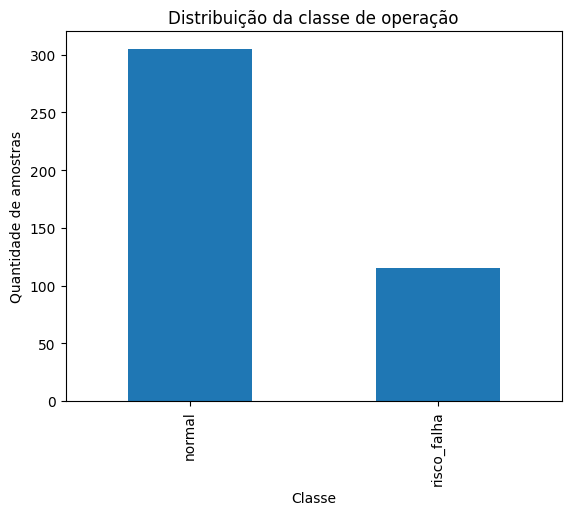

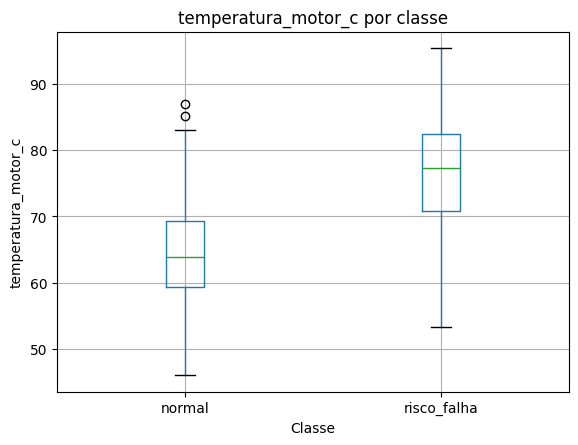

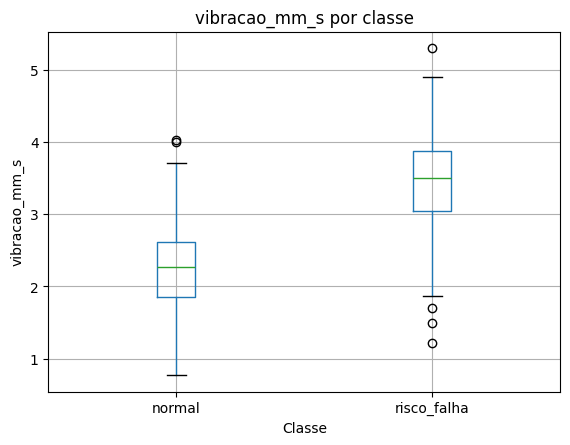

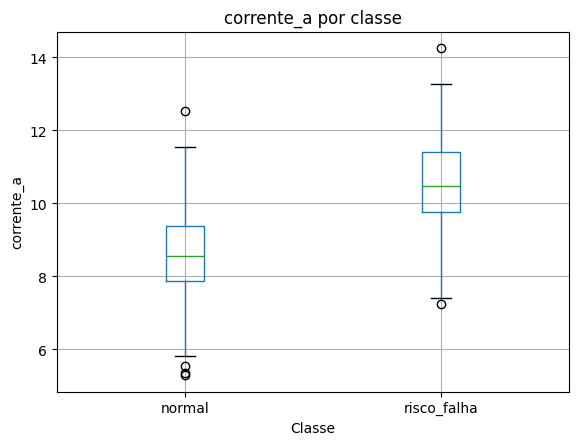

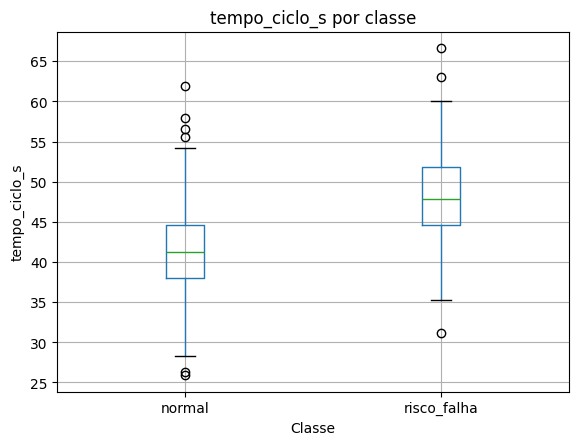

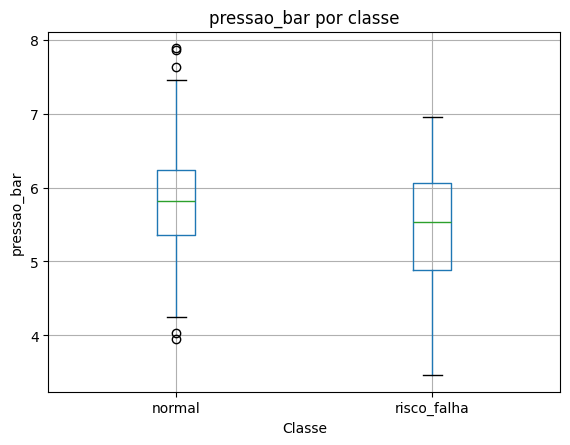

In [ ]:
# Célula 4 - Gere um gráfico da variável alvo
df['classe_operacao'].value_counts().plot(kind='bar')
plt.title('Distribuição da classe de operação')
plt.xlabel('Classe')
plt.ylabel('Quantidade de amostras')
plt.show()


# Célula 5 - Comparação de variáveis numéricas por classe
variaveis_numericas = ['temperatura_motor_c', 'vibracao_mm_s', 'corrente_a', 'tempo_ciclo_s', 'pressao_bar']

for coluna in variaveis_numericas:
    df.boxplot(column=coluna, by='classe_operacao')
    plt.title(f'{coluna} por classe')
    plt.suptitle('')
    plt.xlabel('Classe')
    plt.ylabel(coluna)
    plt.show()

## 3. Preparação dos dados

Complete os campos para separar entradas, saída, colunas numéricas e categóricas.

In [ ]:
# Célula 5 - Separe X e y
X = df.drop(columns=['id_amostra', 'classe_operacao'])
y = df['classe_operacao'].map({'normal': 0, 'risco_falha': 1})

colunas_numericas = ['temperatura_motor_c', 'vibracao_mm_s', 'corrente_a', 'tempo_ciclo_s', 'pressao_bar']
colunas_categoricas = ['maquina', 'turno']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (315, 7)
Teste: (105, 7)


In [ ]:
# Célula 6 - Monte o pré-processador
preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), colunas_numericas),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), colunas_categoricas)
    ]
)

X_train_prep = preprocessador.fit_transform(X_train)
X_test_prep = preprocessador.transform(X_test)

print('Formato após pré-processamento:', X_train_prep.shape)

Formato após pré-processamento: (315, 12)


## 4. Modelo raso

Treine uma regressão logística para representar um modelo de Machine Learning mais simples.

In [ ]:
# Célula 7 - Treine o modelo raso
modelo_raso = LogisticRegression(max_iter=1000, random_state=42)
modelo_raso.fit(X_train_prep,y_train)

y_pred_raso = modelo_raso.predict(X_test_prep)

print('Acurácia do modelo raso:', accuracy_score(y_test, y_pred_raso))
print(classification_report(y_test, y_pred_raso, target_names=['normal', 'risco_falha']))

Acurácia do modelo raso: 0.9142857142857143
              precision    recall  f1-score   support

      normal       0.92      0.96      0.94        76
 risco_falha       0.88      0.79      0.84        29

    accuracy                           0.91       105
   macro avg       0.90      0.88      0.89       105
weighted avg       0.91      0.91      0.91       105



## 5. Rede neural inicial

Complete a arquitetura da rede neural. Use funções de ativação adequadas para camadas ocultas e saída binária.

In [ ]:
# Célula 8 - Crie a rede neural
tf.random.set_seed(42)

n_entradas = X_train_prep.shape[1]

modelo_dl = Sequential([
    Dense(32, activation='relu', input_shape=(n_entradas,)),
     Dropout(0.15),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_dl.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Célula 9 - Treine a rede neural
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

historico = modelo_dl.fit(
    X_train_prep, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5476 - loss: 0.6911 - val_accuracy: 0.6667 - val_loss: 0.6299
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7698 - loss: 0.5995 - val_accuracy: 0.7143 - val_loss: 0.5650
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8373 - loss: 0.5096 - val_accuracy: 0.7460 - val_loss: 0.5021
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8770 - loss: 0.4360 - val_accuracy: 0.7937 - val_loss: 0.4416
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8889 - loss: 0.3740 - val_accuracy: 0.8730 - val_loss: 0.3856
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9048 - loss: 0.3263 - val_accuracy: 0.9206 - val_loss: 0.3411
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8968 - loss: 0.2803 - val_accuracy: 0.9206 - val_loss: 0.3103
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9127 - loss: 0.2506 - val_accuracy: 0.9048 - val_los

In [ ]:
# Célula 10 - Avalie a rede neural
probabilidades = modelo_dl.predict(X_test_prep).ravel()
y_pred_dl = (probabilidades >= 0.5).astype(int)

print('Acurácia da rede neural:', accuracy_score(y_test, y_pred_dl))
print(confusion_matrix(y_test, y_pred_dl))
print(classification_report(y_test, y_pred_dl, target_names=['normal', 'risco_falha']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Acurácia da rede neural: 0.9238095238095239
[[73  3]
 [ 5 24]]
              precision    recall  f1-score   support

      normal       0.94      0.96      0.95        76
 risco_falha       0.89      0.83      0.86        29

    accuracy                           0.92       105
   macro avg       0.91      0.89      0.90       105
weighted avg       0.92      0.92      0.92       105



,Modelo,Acurácia
0,Regressão Logística - modelo raso,0.914286
1,Rede Neural - Deep Learning inicial,0.923810


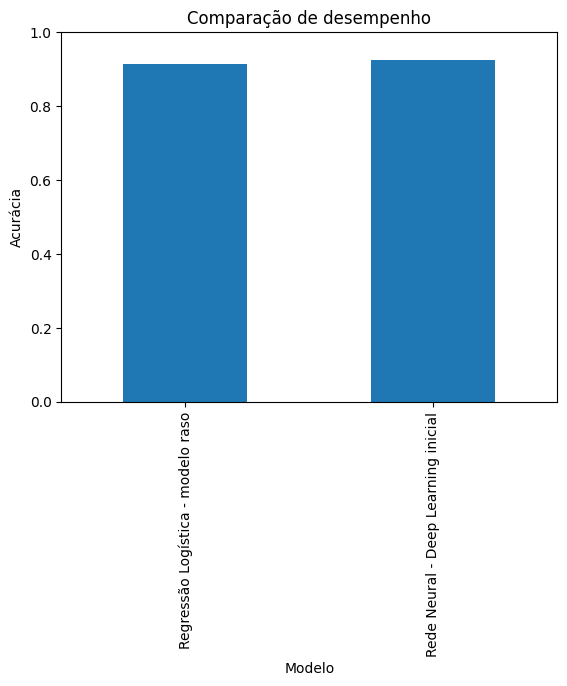

In [ ]:
# Célula 11 - Compare os modelos
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Logística - modelo raso', 'Rede Neural - Deep Learning inicial'],
    'Acurácia': [accuracy_score(y_test, y_pred_raso), accuracy_score(y_test, y_pred_dl)]
})

display(comparacao)
comparacao.plot(x='Modelo', y='Acurácia', kind='bar', legend=False)
plt.ylim(0, 1)
plt.title('Comparação de desempenho')
plt.ylabel('Acurácia')
plt.show()

## 6. Questões técnicas para responder

Responda no próprio notebook:

1. O que é Inteligência Artificial?

**Resposta:** Campo da computação que cria sistemas capazes de realizar
tarefas que normalmente exigiriam inteligência humana.

2. Qual a diferença entre Machine Learning e Deep Learning?

**Resposta:** Machine Learning usa algoritmos que aprendem padrões a partir dos dados. Deep Learning é uma subárea de ML baseada em redes neurais com múltiplas camadas, capaz de aprender representações complexas.

3. O que diferencia uma rede rasa de uma rede profunda?

**Resposta:** Redes rasas possuem poucas camadas intermediárias. Redes profundas possuem múltiplas camadas ocultas, permitindo maior capacidade de representação.

4. Cite uma aplicação industrial de Deep Learning relacionada à aula.

**Resposta:** Inspeção visual de peças, manutenção preditiva, classificação de falhas, análise de imagens, processamento de chamados técnicos ou automação de atendimento.

5. Por que a atenção a detalhes é importante ao desenvolver modelos de IA?

**Resposta:** Porque pequenos erros em dados, configuração de camadas, métricas, divisão de treino/teste ou interpretação dos resultados podem comprometer o desempenho e a confiabilidade da solução.

## 7. Entrega

Entregue no Google Classroom:

- Notebook preenchido e executado;
- Gráficos gerados;
- Comparação dos modelos;
- Respostas técnicas;
- Breve conclusão sobre a aplicação industrial.

In [ ]:
'''
a = tf.Variable(1) #Escalar
b = tf.Variable([[1,2,3]]) #Matriz de uma dimensão 1D
c = tf.Variable([[1,2,3],[4,5,6]]) #Matriz de duas dimensões 2D
d = tf.Variable([[[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]]]) #Tensor de três dimensões 3D

soma = b + c
print(soma)

dividir = c / a
print(dividir)

"""
print(a)
print(b)
print(c)
print(d)
'''

'\na = tf.Variable(1) #Escalar\nb = tf.Variable([[1,2,3]]) #Matriz de uma dimensão 1D\nc = tf.Variable([[1,2,3],[4,5,6]]) #Matriz de duas dimensões 2D\nd = tf.Variable([[[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]]]) #Tensor de três dimensões 3D\n\nsoma = b + c \nprint(soma)\n\ndividir = c / a\nprint(dividir)\n\n"""\nprint(a)\nprint(b)\nprint(c)\nprint(d)\n'

In [ ]:
'''
x = tf.constant(2)
print(x)
# x.assert(8) - não é possivel trocar valor de uma constantes
'''

'\nx = tf.constant(2)\nprint(x)\n# x.assert(8) - não é possivel trocar valor de uma constantes \n'

In [ ]:
'''
#numpy

vetor = np.array([1,2,3])
print(vetor)

matriz = np.array([[1,2,3],[4,5,6]])
print(matriz)

resultado = vetor * matriz
print(resultado)
'''

'\n#numpy\n\nvetor = np.array([1,2,3])\nprint(vetor)\n\nmatriz = np.array([[1,2,3],[4,5,6]])\nprint(matriz)\n\nresultado = vetor * matriz\nprint(resultado)\n'